<a href="https://colab.research.google.com/github/Pranav77774/concept-and-technology-of-AI/blob/main/2501565_PranavManSingh_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Healthcare Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings

warnings.filterwarnings("ignore")

In [ ]:
# 1. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/healthcare_dataset.csv')

# 2. Data Cleaning
# Dropping ID-like and high-cardinality strings to prevent RAM crash and improve logic
cols_to_drop = ['Name', 'Doctor', 'Hospital', 'Date of Admission', 'Discharge Date', 'Room Number']
df.drop(columns=cols_to_drop, inplace=True)

In [ ]:
# Checking for null values and duplicates (as in baseline)
print(f"Null values:\n{df.isnull().sum()}")
print(f"Duplicates before: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Null values:
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Insurance Provider    0
Billing Amount        0
Admission Type        0
Medication            0
Test Results          0
dtype: int64
Duplicates before: 534


In [ ]:
# 3. Categorical Encoding (Using the baseline's cat.codes approach)
object_columns = df.select_dtypes(include=['object']).columns
for col in object_columns:
    df[col] = df[col].astype("category").cat.codes

In [ ]:
# 4. Target and Feature Definition
X = df.drop('Test Results', axis=1)
y = df['Test Results']

Outliers clipped using IQR method.


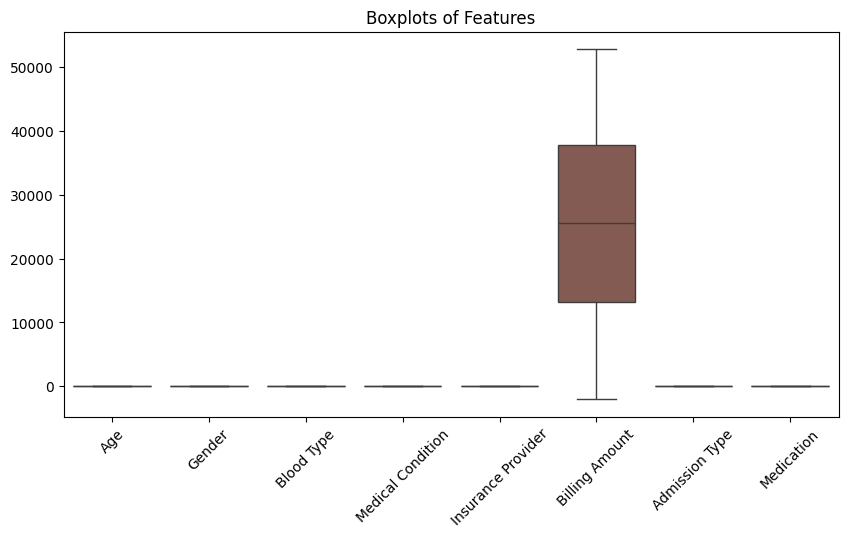

In [ ]:
# 5. Outlier Detection & Clipping
def visualize_outliers(data):
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=data.select_dtypes(include=['float64', 'int64', 'int8']))
    plt.xticks(rotation=45)
    plt.title("Boxplots of Features")
    plt.show()

def clip_outliers(data):
    numerical_features = data.select_dtypes(include=["float64", "int64"]).columns
    for feature in numerical_features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        data[feature] = data[feature].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
    return "Outliers clipped using IQR method."

print(clip_outliers(X))
visualize_outliers(X)

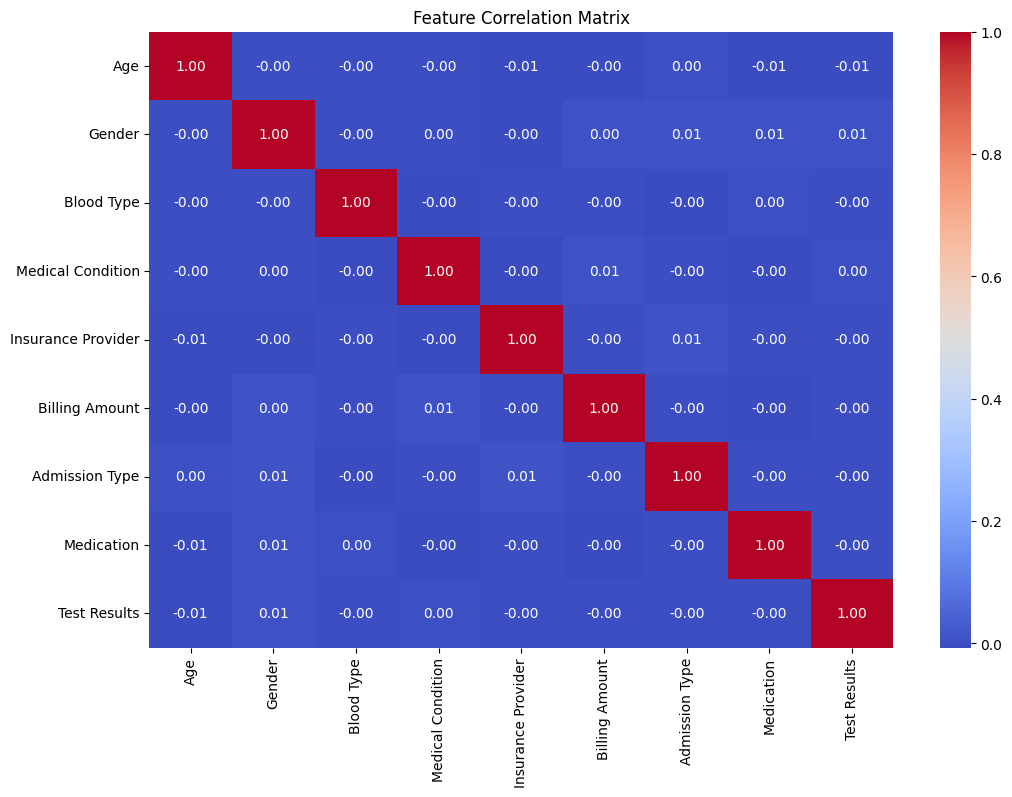

In [ ]:
# 6. EDA - Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
# 7. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Scaling (Required for Neural Networks and Softmax)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# StandardScaler for Logistic, KNN, and MLP
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

In [ ]:
# 8. Custom Softmax Regression
def clip_outliers(data):
    numerical_features = data.select_dtypes(include=["float64", "int64"]).columns
    for feature in numerical_features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Ensure the lower limit is never less than 0
        lower_limit = max(0, Q1 - 1.5 * IQR)
        upper_limit = Q3 + 1.5 * IQR

        data[feature] = data[feature].clip(lower=lower_limit, upper=upper_limit)
    return "Outliers clipped (non-negative constraint applied)."

In [ ]:
# 3. Training & Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# SCALING 1: StandardScaler (For Neural Network and Custom Softmax)
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

In [ ]:
# SCALING 2: MinMaxScaler (FIX for MultinomialNB - ensures values are in [0, 1])
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

In [ ]:
# 4. Task 2: Neural Network (MLP)
# ==========================================
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train_std, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

In [ ]:
# 5. KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)

KNeighborsClassifier()

In [ ]:
# 6. Logistic Regression
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500)
log_reg.fit(X_train_std, y_train)

LogisticRegression(max_iter=500, multi_class='multinomial')

In [ ]:
# 5. Task 3: Primary Models (NB, RF, Custom)
# ==========================================
# Naive Bayes (Using MinMaxScaler data)
nb = MultinomialNB()
nb.fit(X_train_mm, y_train)

MultinomialNB()

In [ ]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# 6. Task 4: Hyperparameter Tuning (Random Forest)
# ==========================================

param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

In [ ]:
# 7. Task 5: Feature Selection
# ==========================================
selector = SelectKBest(score_func=f_classif, k=5)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)
print(f"Selected Features: {X.columns[selector.get_support()].tolist()}")

Selected Features: ['Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount', 'Medication']


In [ ]:
# 8. Task 6: Final Comparative Analysis Table
# ==========================================
models_eval = {
    "Naive Bayes": (nb, X_test_mm),
    "Random Forest (Tuned)": (best_rf, X_test),
    "Neural Network (MLP)": (mlp, X_test_std)
}

results = []
for name, (model, test_data) in models_eval.items():
    preds = model.predict(test_data)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='weighted'),
        "Recall": recall_score(y_test, preds, average='weighted'),
        "F1-Score": f1_score(y_test, preds, average='weighted')
    })

comparison_df = pd.DataFrame(results)
print("\n--- Final Comparative Analysis ---")
print(comparison_df)


--- Final Comparative Analysis ---
                   Model  Accuracy  Precision    Recall  F1-Score
0            Naive Bayes  0.333293   0.330144  0.333293  0.237792
1  Random Forest (Tuned)  0.414676   0.414845  0.414676  0.414568
2   Neural Network (MLP)  0.341722   0.342262  0.341722  0.338136
